In [41]:
import numpy as np 
import pandas as pd 

In [42]:
df = pd.read_csv('newplacementdata - newplacementdata.csv')
df.head(3)

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1


In [43]:
import matplotlib.pyplot as plt 
import seaborn as sns 

In [44]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

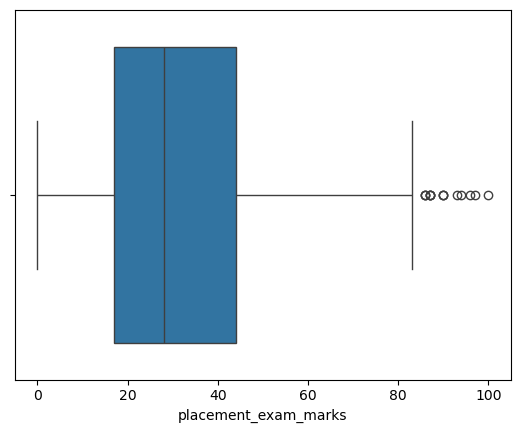

In [45]:
sns.boxplot(x=df['placement_exam_marks'])

In [46]:
# finding IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [47]:
percentile25, percentile75

(np.float64(17.0), np.float64(44.0))

In [48]:
IQR = percentile75 - percentile25
IQR

np.float64(27.0)

In [49]:
upper_limit = percentile75 + 1.5*IQR 
lower_limit = percentile25 - 1.5*IQR

In [50]:
upper_limit, lower_limit

(np.float64(84.5), np.float64(-23.5))

# Finding our outliers

In [51]:
df[(df['placement_exam_marks']>upper_limit) | (df['placement_exam_marks']<lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [52]:
# Trimming --> 4(lower)....1, upper(25)....(50)---> here 1, 50 are outliers
# lower(4) <---> uper(25) mid data 

# Capping ---> 4(lower)....1, upper(25)....(50) ---> capping lower point lowest point(1)
# upper point (50) --> range expand --> outliers remove 

In [53]:
# Trimming (Outliers Removing Technique 1)

In [54]:
newdf = df[df['placement_exam_marks']<upper_limit]

In [55]:
newdf

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0
...,...,...,...
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
998,8.62,46,1


In [56]:
# comparision

<Axes: xlabel='placement_exam_marks'>

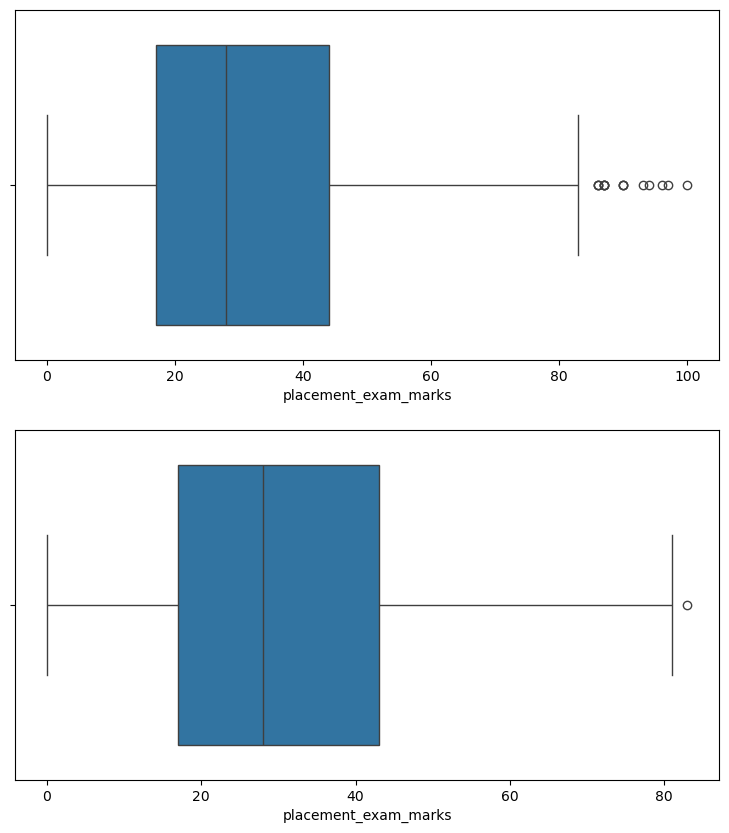

In [57]:
plt.figure(figsize=(20,10))

plt.subplot(222)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(x=newdf['placement_exam_marks'])

In [58]:
# Capping (Outlier Removing Technique 2)

In [59]:
new_df_cap = df.copy()

In [60]:
# min=5, max = 15 
# min 4, 3, 1 
# max = 20,30,40 

# updated_min_value = 1 
# updated_max_value = 50 

In [61]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks']>upper_limit, upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit, lower_limit,  
        new_df_cap['placement_exam_marks']
    )
)

# new_df_cap['placement_exam_marks'] = new_df_cap['placement_exam_marks'].clip(lower_limit, upper_limit)

In [62]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [63]:
# Comparision

<Axes: xlabel='placement_exam_marks'>

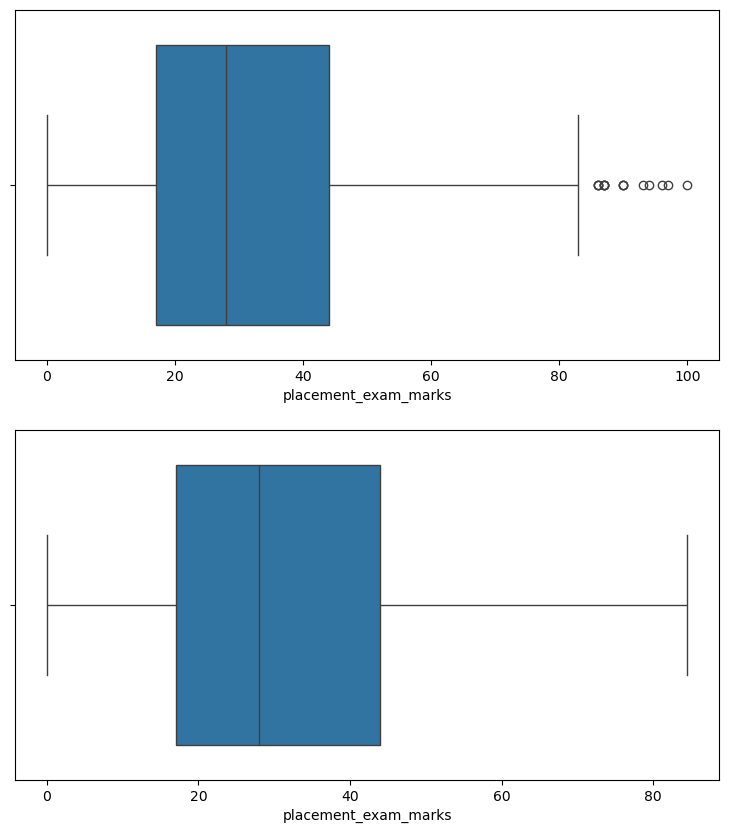

In [64]:
plt.figure(figsize=(20,10))

plt.subplot(222)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(x=new_df_cap['placement_exam_marks'])